# Deel 2: Dynamica, Veerontwerp en Vliegwiel


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import math
%matplotlib widget

### Setup

Deze cel herdefiniëert alle parameters en berekent het kinematisch profiel. Pas parameters hier aan en herbereken alle cellen bij een wat-als-vraag.

In [6]:
# ============================================================
# Parameters (aanpassen voor wat-als-vragen)
# ============================================================

# Tijds- en snelheidsgegevens
T_cyclus = 0.5                     # Cyclustijd in s
omega = 2.0 * np.pi / T_cyclus     # Toerental in rad/s

# Nokgeometrie (overgenomen uit Nok_1 na K-M analyse)
R_0 = 0.050                        # Steekcirkelstraal in m
R_r = 0.015                        # Straal volgerwiel in m  (= R_r, prof's notatie)
e = 0.0                            # Excentriciteit volger in m

# Massa en wrijving
m_volger = 29.0                    # Equivalente massa in kg
mu = 0.1                           # Wrijvingscoëfficiënt
g = 9.81                           # Zwaartekrachtversnelling in m/s^2

# Veer — k_veer is een vrije ontwerpaankeuze; F_preload volgt uit de krachtenbalans (zie §1)
zeta   = 0.094                     # Relatieve demping
k_veer = 25000.0                   # Veerstijfheid in N/m
c_demping = zeta * 2 * np.sqrt(k_veer * m_volger)

# Vliegwiel
K_gewenst = 0.05                   # Fluctuatiecoëfficiënt [-]

# ============================================================
# Bewegingswetten en nokprofiel (identiek aan Nok_1)
# ============================================================

def dwell_law(tau):
    zeros = np.zeros_like(tau)
    return zeros, zeros, zeros, zeros

def cycloid_law(tau):
    y = tau - np.sin(2 * np.pi * tau) / (2 * np.pi)
    dy = 1.0 - np.cos(2 * np.pi * tau)
    ddy = 2 * np.pi * np.sin(2 * np.pi * tau)
    dddy = 4 * np.pi**2 * np.cos(2 * np.pi * tau)
    return y, dy, ddy, dddy

def poly5_law(tau):
    y = 10 * tau**3 - 15 * tau**4 + 6 * tau**5
    dy = 30 * tau**2 - 60 * tau**3 + 30 * tau**4
    ddy = 60 * tau - 180 * tau**2 + 120 * tau**3
    dddy = 60 - 360 * tau + 360 * tau**2
    return y, dy, ddy, dddy

theta_deg = np.linspace(0, 360, 36001)
theta_rad = np.deg2rad(theta_deg)

def calc_kinematics_for_profile(theta_array, segments):
    s, v, a, j = (np.zeros_like(theta_array) for _ in range(4))
    for (start_hoek, eind_hoek, start_lift, eind_lift, type_wet) in segments:
        beta = eind_hoek - start_hoek
        if beta <= 0:
            beta += 360.0
        beta_rad = np.deg2rad(beta)
        h = eind_lift - start_lift
        shifted_deg = (theta_array - start_hoek) % 360.0
        mask = (shifted_deg >= 0) & (shifted_deg <= beta)
        tau = shifted_deg[mask] / beta
        if type_wet == 'cycloid':
            y, dy, ddy, dddy = cycloid_law(tau)
        elif type_wet == 'poly5':
            y, dy, ddy, dddy = poly5_law(tau)
        else:
            y, dy, ddy, dddy = dwell_law(tau)
        s[mask] = start_lift + h * y
        if type_wet != 'dwell':
            v[mask] = (h / beta_rad) * dy * omega
            a[mask] = (h / beta_rad**2) * ddy * omega**2
            j[mask] = (h / beta_rad**3) * dddy * omega**3
    return s, v, a, j

profiel_segmenten = [
    (10,   65,  0.000, 0.010, 'poly5'),
    (65,   95,  0.010, 0.010, 'dwell'),
    (95,  210,  0.010, 0.050, 'poly5'),
    (210, 350,  0.050, 0.000, 'poly5'),
    (350,  10,  0.000, 0.000, 'dwell'),
]

s_profiel, v_profiel, a_profiel, j_profiel = calc_kinematics_for_profile(theta_deg, profiel_segmenten)

ds_dtheta   = v_profiel / omega
d2s_dtheta2 = a_profiel / omega**2
s_base      = np.sqrt((R_0 + R_r)**2 - e**2)
s_tot       = s_base + s_profiel
alpha_rad   = np.arctan((ds_dtheta - e) / s_tot)

X_pitch = s_tot * np.sin(theta_rad) + e * np.cos(theta_rad)
Y_pitch = s_tot * np.cos(theta_rad) - e * np.sin(theta_rad)
X_nok   = X_pitch - R_r * np.sin(theta_rad - alpha_rad)
Y_nok   = Y_pitch - R_r * np.cos(theta_rad - alpha_rad)

### 1. Inverse Dynamica: Krachtenbalans

De normaalkracht op de nok volgt uit d'Alembert voor de translerende volger. De prof's aanpak (Kloomok-Muffley):

$$F_{normaal} = \frac{k \cdot s + F_{preload}}{\cos\alpha} + \frac{F_{extern}}{\cos\alpha} + \frac{m \cdot \ddot{s}}{\cos\alpha}$$

De `spring_preload` wordt bepaald als de kleinste waarde zodat $F_{normaal} \geq 0$ voor alle $\theta$.

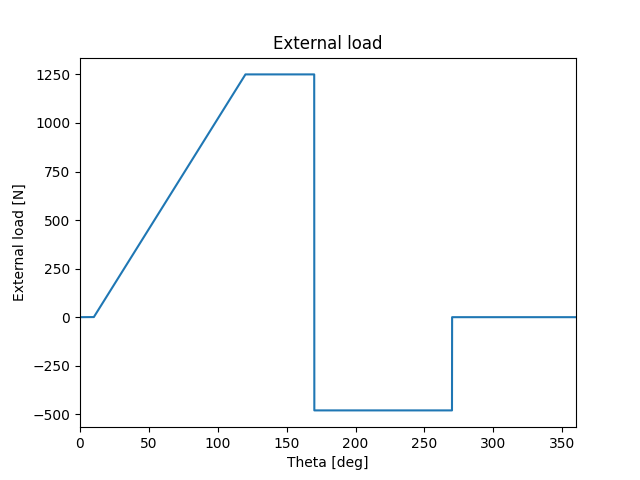

spring_constant    = 25.0 N/mm
spring_preload_min = 284.5 N
spring_preload     = 300 N


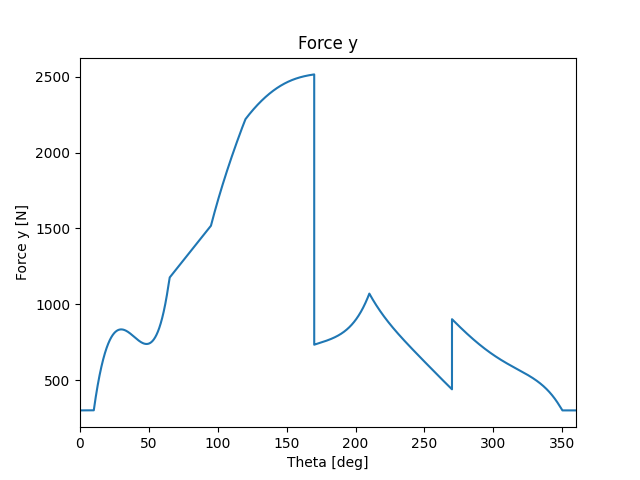

Minimale normaalkracht: 300 N


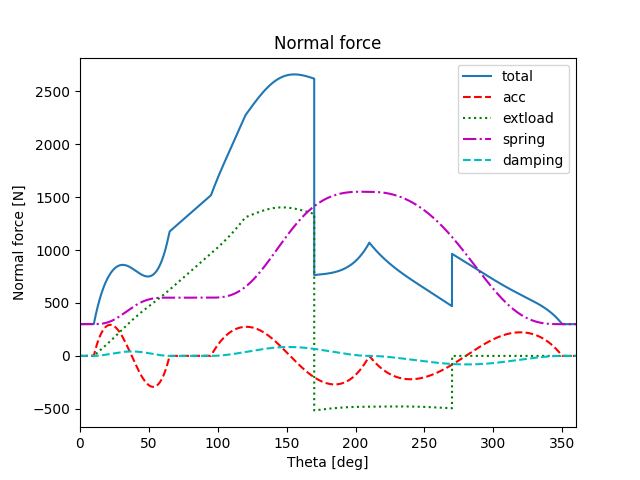

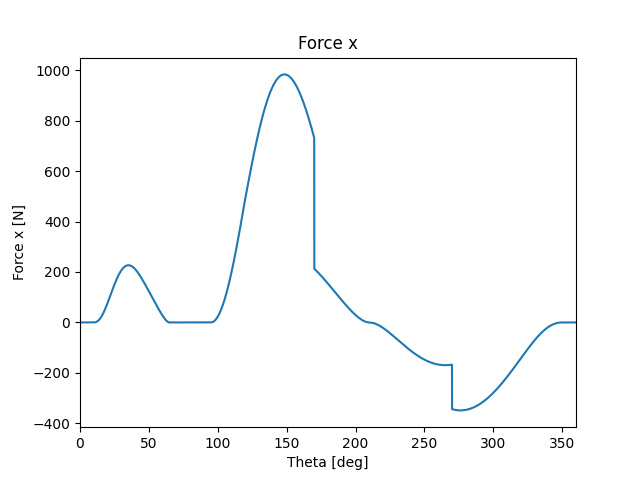

In [7]:
# ============================================================
# Schakelaars (aanpassen voor wat-als-vragen)
# ============================================================
include_gravity  = True   # Zwaartekracht aan (True) of uit (False)
include_friction = True   # Wrijving aan (True) of uit (False)
# ============================================================

# Externe kracht — identiek aan prof's addLoadSegment
dtheta_deg = theta_deg[1] - theta_deg[0]
ext_load   = np.zeros_like(theta_deg)

def addLoadSegment(startangleload, endangleload, startload, endload):
    global ext_load
    start_index   = int(startangleload / dtheta_deg)
    end_index     = int(endangleload   / dtheta_deg)
    theta_segment = theta_deg[start_index:end_index]
    ext_load[start_index:end_index] = (
        (endload - startload) / (endangleload - startangleload)
        * (theta_segment - startangleload) + startload
    )
    return ext_load

def plotExternalLoad(theta_deg, ext_load):
    plt.figure()
    plt.plot(theta_deg, ext_load)
    plt.xlabel('Theta [deg]')
    plt.ylabel('External load [N]')
    plt.xlim([0, 360])
    plt.title('External load')

ext_load = addLoadSegment( 10, 120,    0, 1250)
ext_load = addLoadSegment(120, 170, 1250, 1250)
ext_load = addLoadSegment(170, 270, -480, -480)
plotExternalLoad(theta_deg, ext_load)
plt.show()

# ============================================================
# Veerontwerp: kies spring_constant, bepaal spring_preload
# Eenheden: lift in mm, acc in mm/rad², spring_constant in N/mm, preload in N
# Zwaartekracht wordt verwerkt in de preload: hogere preload compenseert het gewicht.
# ============================================================
rpm             = 60 / T_cyclus         # = 120 rpm
mass            = m_volger              # 29 kg
spring_constant = k_veer / 1000        # 25 N/mm  (k_veer = 25 000 N/m)
lift_mm         = s_profiel * 1000     # heffing in mm
acc_mm          = d2s_dtheta2 * 1000  # d²s/dθ² in mm/rad²

F_grav_toggle = mass * 9.81 if include_gravity else 0.0

_omega = rpm * 2 * np.pi / 60
spring_preload_min = np.max(
    -(lift_mm * spring_constant + ext_load + mass * (acc_mm / 1000) * _omega**2)
    + F_grav_toggle
)
spring_preload = max(0, math.ceil(spring_preload_min / 100) * 100)

print(f"spring_constant    = {spring_constant} N/mm")
print(f"spring_preload_min = {spring_preload_min:.1f} N")
print(f"spring_preload     = {spring_preload} N")

# ============================================================
# Krachtenbalans
# vel_mrad : ds/dθ [m/rad] — voor dempingskracht
# c_demping: absolute dempingsconstante [N·s/m] — berekend in setup
# ============================================================
def calculateForce(rpm, lift, spring_constant, spring_preload, pressure_angle,
                   ext_load, mass, acc, vel_mrad=None, c_demping=0.0):
    omega_fn = rpm * 2 * np.pi / 60
    normalforce_spring = (lift * spring_constant + spring_preload) / np.cos(pressure_angle)
    normalforce_load   = ext_load / np.cos(pressure_angle)
    normalforce_acc    = mass * acc / 1000 * (omega_fn**2) / np.cos(pressure_angle)
    # Dempingskracht: c [N·s/m] * ds/dθ [m/rad] * ω [rad/s] = N
    if vel_mrad is not None:
        normalforce_damp = c_demping * vel_mrad * omega_fn / np.cos(pressure_angle)
    else:
        normalforce_damp = np.zeros_like(lift)
    normalforce_tot = (normalforce_spring + normalforce_load
                       + normalforce_acc + normalforce_damp)
    force_x = normalforce_tot * np.sin(pressure_angle)
    force_y = normalforce_tot * np.cos(pressure_angle)
    return (normalforce_tot, normalforce_acc, normalforce_load,
            normalforce_spring, normalforce_damp, force_x, force_y)

# ============================================================
# Grafieken
# ============================================================
def plotForces(theta_deg, normalforce_tot, normalforce_acc, normalforce_load,
               normalforce_spring, normalforce_damp, force_x, force_y):
    plt.figure()
    plt.plot(theta_deg, normalforce_tot)
    plt.plot(theta_deg, normalforce_acc, '--r')
    plt.plot(theta_deg, normalforce_load, ':g')
    plt.plot(theta_deg, normalforce_spring, '-.m')
    plt.plot(theta_deg, normalforce_damp, '--c')
    plt.xlabel('Theta [deg]')
    plt.ylabel('Normal force [N]')
    plt.xlim([0, 360])
    plt.legend(['total', 'acc', 'extload', 'spring', 'damping'])
    plt.title('Normal force')

    plt.figure()
    plt.plot(theta_deg, force_x)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Force x [N]')
    plt.xlim([0, 360])
    plt.title('Force x')

    plt.figure()
    plt.plot(theta_deg, force_y)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Force y [N]')
    plt.xlim([0, 360])
    plt.title('Force y')

# ---------------------------------------------------------------------------
# Berekeningen
(normalforce_tot, normalforce_acc, normalforce_load, normalforce_spring,
 normalforce_damp, force_x, force_y) = calculateForce(
    rpm, lift_mm, spring_constant, spring_preload, alpha_rad, ext_load, mass, acc_mm,
    vel_mrad=ds_dtheta, c_demping=c_demping
)

# Wrijving toggle
if include_friction:
    friction_factor    = 1.0 / (1.0 - mu * np.abs(np.tan(alpha_rad)) * np.sign(v_profiel))
    normalforce_tot    = normalforce_tot    * friction_factor
    normalforce_acc    = normalforce_acc    * friction_factor
    normalforce_load   = normalforce_load   * friction_factor
    normalforce_spring = normalforce_spring * friction_factor
    normalforce_damp   = normalforce_damp   * friction_factor
    force_x = normalforce_tot * np.sin(alpha_rad)
    force_y = normalforce_tot * np.cos(alpha_rad)

# F_nok_verticaal voor vermogensberekening (§2)
F_nok_verticaal = normalforce_tot * np.cos(alpha_rad)

plotForces(theta_deg, normalforce_tot, normalforce_acc, normalforce_load,
           normalforce_spring, normalforce_damp, force_x, force_y)
plt.show()

print(f"Minimale normaalkracht: {np.min(normalforce_tot):.0f} N")

### 2. Aandrijfvermogen en Vliegwiel

Het aandrijfkoppel op de nok-as volgt uit virtuele arbeid. De drukhoek is daarin al verwerkt via $F_{nok,vert}$:

$$M(\theta) = F_{nok,vert} \cdot \frac{ds}{d\theta}$$

Het gemiddeld vermogen en de energiefluctuatie bepalen de benodigde vliegwieltraagheid:

$$P_{gem} = \frac{1}{2\pi} \int_0^{2\pi} M(\theta)\,\omega\,d\theta, \qquad I_{vliegwiel} = \frac{\Delta E}{K \cdot \omega^2}$$

<>:41: SyntaxWarning: invalid escape sequence '\D'
<>:41: SyntaxWarning: invalid escape sequence '\D'
C:\Users\WELL_ASUS_BUP\AppData\Local\Temp\ipykernel_24040\1319578371.py:41: SyntaxWarning: invalid escape sequence '\D'
  ax_E.set_title(f'Energiefluctuatie  —  $\Delta E$ = {Delta_E:.4f} J')


Gemiddeld vermogen:   110 W
Gemiddeld koppel:     8.78 Nm
Energiefluctuatie:    65.9 J
Vliegwieltraagheid:   8.35 kg m^2


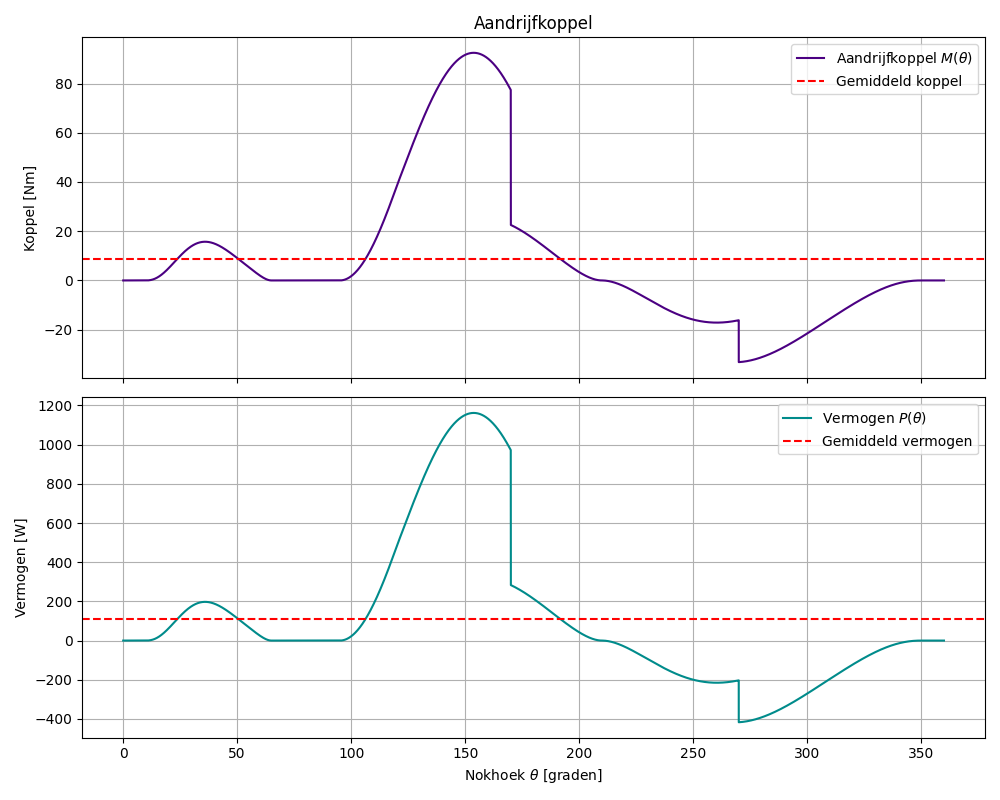

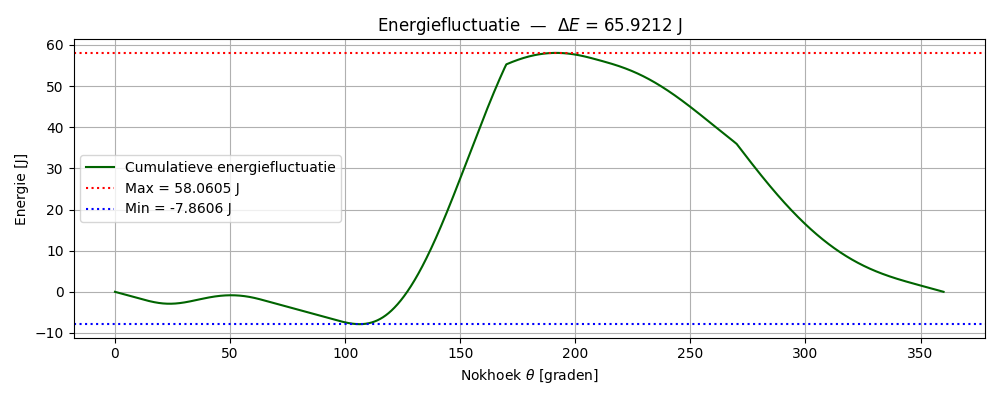

In [8]:
M_aandrijf = F_nok_verticaal * (v_profiel / omega)
P_aandrijf = M_aandrijf * omega

P_gemiddeld = np.trapezoid(P_aandrijf, theta_rad) / (2 * np.pi)
M_gemiddeld = P_gemiddeld / omega

dtheta_rad = theta_rad[1] - theta_rad[0]
E_fluct    = np.cumsum((M_aandrijf - M_gemiddeld) * dtheta_rad)
Delta_E    = np.max(E_fluct) - np.min(E_fluct)
I_vliegwiel = Delta_E / (K_gewenst * omega**2)

print(f"Gemiddeld vermogen:   {P_gemiddeld:.3g} W")
print(f"Gemiddeld koppel:     {M_gemiddeld:.3g} Nm")
print(f"Energiefluctuatie:    {Delta_E:.3g} J")
print(f"Vliegwieltraagheid:   {I_vliegwiel:.3g} kg m^2")

fig4, (ax_torque, ax_power) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax_torque.plot(theta_deg, M_aandrijf, label=r'Aandrijfkoppel $M(\theta)$', color='indigo')
ax_torque.axhline(M_gemiddeld, color='r', linestyle='--', label='Gemiddeld koppel')
ax_torque.set_ylabel('Koppel [Nm]')
ax_torque.set_title('Aandrijfkoppel')
ax_torque.grid(True)
ax_torque.legend()

ax_power.plot(theta_deg, P_aandrijf, label=r'Vermogen $P(\theta)$', color='darkcyan')
ax_power.axhline(P_gemiddeld, color='r', linestyle='--', label='Gemiddeld vermogen')
ax_power.set_ylabel('Vermogen [W]')
ax_power.set_xlabel(r'Nokhoek $\theta$ [graden]')
ax_power.grid(True)
ax_power.legend()
plt.tight_layout()
plt.show()

# Cumulatieve energiefluctuatie — ΔE visueel
fig5, ax_E = plt.subplots(figsize=(10, 4))
ax_E.plot(theta_deg, E_fluct, color='darkgreen', label='Cumulatieve energiefluctuatie')
ax_E.axhline(np.max(E_fluct), color='r', linestyle=':', label=f'Max = {np.max(E_fluct):.4f} J')
ax_E.axhline(np.min(E_fluct), color='b', linestyle=':', label=f'Min = {np.min(E_fluct):.4f} J')
ax_E.set_ylabel('Energie [J]')
ax_E.set_xlabel(r'Nokhoek $\theta$ [graden]')
ax_E.set_title(f'Energiefluctuatie  —  $\Delta E$ = {Delta_E:.4f} J')
ax_E.grid(True)
ax_E.legend()
plt.tight_layout()
plt.show()

### 3. Mondelinge Vragen — Dynamica & Vliegwiel

**V: Hoe kies je $F_{preload}$?**
De voorspanning moet net groot genoeg zijn zodat $F_{normaal} > 0$ voor alle $\theta$ (geen zweefgedrag). Te hoog kiezen is negatief: de normaalkracht stijgt onnodig, wat meer wrijvingsverliezen en hogere motorbelasting geeft. In de praktijk kies je $F_{preload}$ met ~50–100 N marge boven de minimale waarde. Zwaartekracht is hier al in verrekend via de preload.

**V: Wat als $T_{cyclus}$ halveert (2× sneller draaien)?**
Het geometrisch nokprofiel verandert niet: $s(\theta)$ is puur geometrisch. Maar $\omega$ verdubbelt → versnellingen stijgen kwadratisch ($\ddot{s} \propto \omega^2$) → inertiële krachten nemen met factor 4 toe. Het vliegwiel mag kleiner ($I \propto \Delta E / \omega^2$), maar de motor moet véél meer koppel leveren.

**V: Vliegwiel op nokas of motoras?**
Op de **nokas**: pieken worden direct, zonder transmissiereductie, opgevangen. Op de **motoras**: de reductie vermindert de inertiewerking ($I_{eff} = I / i^2$) — het vliegwiel is dan veel minder effectief tenzij het proportioneel groter wordt. Voorkeur: nokas.

**V: Mogelijke singulariteiten in het mechanisme?**
- Drukhoek $\alpha = 90°$: krachtoverdracht is onmogelijk
- $\mu \cdot |\tan\alpha| \geq 1$: noemer van $F_{normaal}$ wordt nul → zelfblokkering
- $\rho_{pitch} \leq R_r$: ondersnijding, mechanisme loopt vast
- $F_{normaal} \leq 0$: contactverlies (zweefgedrag van de volger)

**V: Onbalans-eigenschappen van de nok?**
Een nok is in statische onbalans: het massamiddelpunt valt niet samen met de rotatie-as. Dit veroorzaakt een centrifugale kracht $F = m \cdot e_{cm} \cdot \omega^2$ die het frame doet trillen en de lagers belast. Gevolgen: vermoeiing, trillingen, precisieverlies. Oplossing: tegengewicht aan de andere kant van de as, of materiaalverwijdering aan de uitstulpingskant van de nok.

**V: Waarom dempingskracht in de normaalkracht?**
De dempingskracht $F_d = c \cdot \dot{s}$ werkt langs de bewegingsrichting van de volger. Via de drukhoek $\alpha$ wordt die omgezet naar een bijdrage in de normaalkracht: $F_{d,norm} = c \cdot \dot{s} / \cos\alpha$. Bij kleine drukhoeken is het effect gering; het wordt pas significant bij $\alpha > 20°$.